In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Retail_Sales.csv")

In [5]:
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


In [6]:
print("Number of rows and columns:", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Number of rows and columns: (2000, 11)

Column data types:
transactions_id      int64
sale_date           object
sale_time           object
customer_id          int64
gender              object
age                float64
category            object
quantiy            float64
price_per_unit     float64
cogs               float64
total_sale         float64
dtype: object

Missing values:
transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantiy             3
price_per_unit      3
cogs                3
total_sale          3
dtype: int64


# Retail Sales Exploratory Data Analysis

## 1. Introduction

This project performs an Exploratory Data Analysis (EDA) on a retail sales dataset to identify sales trends, customer behaviour patterns and product category performance.

The analysis covers data inspection, data cleaning, descriptive statistics, time-based sales trends, customer demographics, product category analysis, correlation analysis and business insights.

The objective is to use data-driven findings to provide actionable recommendations for improving retail business performance.

## 2. Dataset Overview

The dataset contains 2,000 retail transaction records and 11 columns covering transaction details, customer demographics, product categories, pricing, cost and sales information.

The dataset includes customer gender and age, allowing us to analyse customer demographics and purchasing behaviour.

During the initial inspection, missing values were identified in the `age`, `quantity`, `price_per_unit`, `cogs` and `total_sale` columns. These missing values will be handled during the data cleaning stage.

In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Summary statistics for numerical columns
df.describe()

,transactions_id,customer_id,age,quantiy,price_per_unit,cogs,total_sale
count,2000.000000,2000.000000,1990.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,1000.500000,66.341500,41.343216,2.512769,180.117677,95.023886,456.544817
std,577.494589,44.937185,13.668167,1.132708,189.685225,121.898695,560.101381
min,1.000000,1.000000,18.000000,1.000000,25.000000,6.250000,25.000000
25%,500.750000,24.000000,29.000000,1.000000,30.000000,13.000000,60.000000
50%,1000.500000,69.000000,42.000000,3.000000,50.000000,27.500000,150.000000
75%,1500.250000,102.000000,53.000000,4.000000,300.000000,147.000000,900.000000
max,2000.000000,155.000000,64.000000,4.000000,500.000000,620.000000,2000.000000


In [9]:
# Display rows containing missing values
missing_rows = df[df.isnull().any(axis=1)]

print("Number of rows with missing values:", len(missing_rows))

missing_rows

Number of rows with missing values: 13


,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
24,432,2022-03-10,11:31:00,17,Female,NaN,Electronics,2.0,500.0,190.00,1000.0
25,1367,2022-04-15,11:38:00,16,Female,NaN,Electronics,1.0,50.0,15.50,50.0
26,1391,2022-03-01,11:29:00,130,Male,NaN,Beauty,2.0,25.0,9.25,50.0
27,1432,2022-12-25,06:24:00,67,Female,NaN,Electronics,2.0,500.0,245.00,1000.0
28,150,2022-04-13,08:25:00,89,Female,NaN,Electronics,4.0,30.0,16.20,120.0
29,845,2022-10-27,10:12:00,25,Male,NaN,Clothing,1.0,500.0,145.00,500.0
30,1150,2022-08-22,10:04:00,77,Female,NaN,Electronics,4.0,30.0,10.20,120.0
31,1845,2022-05-24,07:06:00,94,Male,NaN,Clothing,1.0,500.0,185.00,500.0
32,797,2022-09-16,06:38:00,116,Male,NaN,Clothing,3.0,25.0,10.75,75.0
33,921,2022-09-28,09:34:00,101,Male,NaN,Electronics,3.0,25.0,8.00,75.0


## 3. Data Cleaning

### Handling Missing Values

The dataset contains 22 missing values across 13 records.

- The `age` column has 10 missing values. These values will be replaced using the median age because the median is less affected by unusually high or low ages.
- Three records have missing values in `quantity`, `price_per_unit`, `cogs`, and `total_sale` simultaneously. Since these are essential sales-related variables and cannot be reliably reconstructed from the available information, these three records will be removed.
- No duplicate records were found in the dataset.

In [10]:
# Creating a copy so the original dataset remains unchanged
df_clean = df.copy()

# Filling missing ages with the median age
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Remove rows where all key sales fields are missing
df_clean = df_clean.dropna(
    subset=['quantiy', 'price_per_unit', 'cogs', 'total_sale']
)

# Rename the misspelled column
df_clean.rename(columns={'quantiy': 'quantity'}, inplace=True)

# Convert sale_date to datetime
df_clean['sale_date'] = pd.to_datetime(df_clean['sale_date'])

print("Original rows:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 2000
Rows after cleaning: 1997
Rows removed: 3


In [11]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nData types after cleaning:")
print(df_clean.dtypes)

Missing values after cleaning:
transactions_id    0
sale_date          0
sale_time          0
customer_id        0
gender             0
age                0
category           0
quantity           0
price_per_unit     0
cogs               0
total_sale         0
dtype: int64

Data types after cleaning:
transactions_id             int64
sale_date          datetime64[ns]
sale_time                  object
customer_id                 int64
gender                     object
age                       float64
category                   object
quantity                  float64
price_per_unit            float64
cogs                      float64
total_sale                float64
dtype: object


## 4. Descriptive Statistics

Descriptive statistics are used to understand the central tendency and variability of the numerical variables in the dataset.

The analysis includes the mean, median, mode and standard deviation for each numerical variable.

In [12]:
# Select numerical columns
numeric_cols = df_clean.select_dtypes(include='number').columns

# Calculate descriptive statistics
descriptive_stats = pd.DataFrame({
    'Mean': df_clean[numeric_cols].mean(),
    'Median': df_clean[numeric_cols].median(),
    'Mode': df_clean[numeric_cols].mode().iloc[0],
    'Standard Deviation': df_clean[numeric_cols].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
transactions_id,1000.676014,1001.0,1.0,577.833658
customer_id,66.319479,69.0,1.0,44.939785
age,41.354532,42.0,42.0,13.628462
quantity,2.512769,3.0,4.0,1.132708
price_per_unit,180.117677,50.0,50.0,189.685225
cogs,95.023886,27.5,13.5,121.898695
total_sale,456.544817,150.0,50.0,560.101381


## 5. Time Series Analysis

Time series analysis is used to understand how retail sales change over time. Monthly and quarterly sales trends can help identify seasonal patterns, periods of high demand and changes in overall business performance.

In [13]:
# Convert sale_date to datetime
df_clean['sale_date'] = pd.to_datetime(df_clean['sale_date'])

# Create month column
df_clean['month'] = df_clean['sale_date'].dt.to_period('M')

# Calculate monthly sales
monthly_sales = df_clean.groupby('month')['total_sale'].sum()

monthly_sales

,total_sale
month,
2022-01,22635.0
2022-02,16110.0
2022-03,24505.0
2022-04,28705.0
2022-05,24980.0
2022-06,20700.0
2022-07,22195.0
2022-08,21195.0
2022-09,61770.0


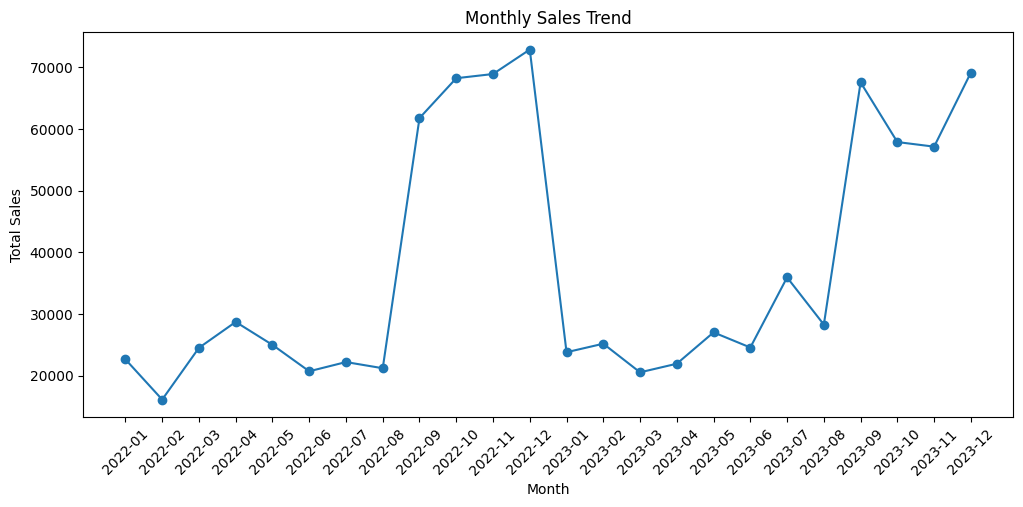

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

### Observation

The monthly sales trend shows considerable variation throughout the two-year period.

Sales were relatively low during several months in early 2022, followed by a sharp increase from September to December 2022, with December reaching the highest sales level in 2022.

Sales decreased significantly in early 2023, but increased again from September 2023 onwards. The strong rise toward the end of 2023 suggests that sales may be influenced by seasonal demand or year-end purchasing patterns.

In [15]:
# Create quarter column
df_clean['quarter'] = df_clean['sale_date'].dt.to_period('Q')

# Calculate quarterly sales
quarterly_sales = df_clean.groupby('quarter')['total_sale'].sum()

quarterly_sales

,total_sale
quarter,
2022Q1,63250.0
2022Q2,74385.0
2022Q3,105160.0
2022Q4,210030.0
2023Q1,69490.0
2023Q2,73490.0
2023Q3,131755.0
2023Q4,184160.0


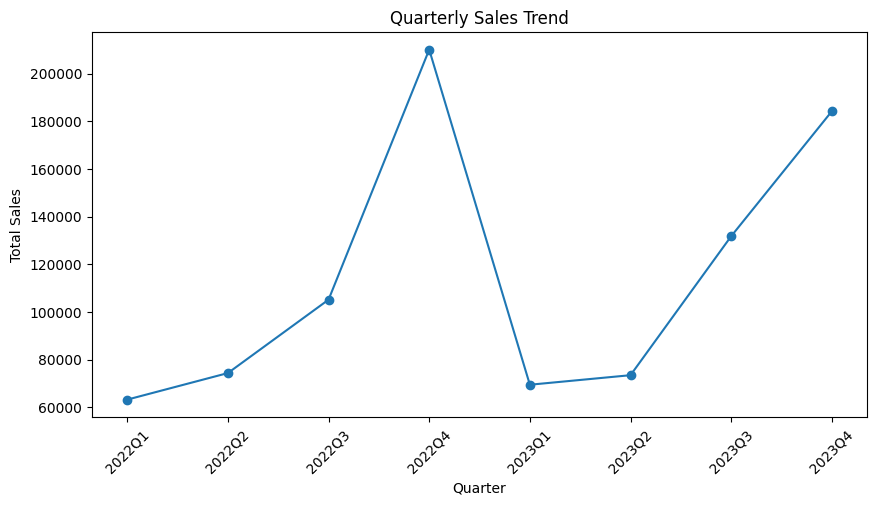

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()

Observation: Quarterly sales show significant variation over time. Sales reached their highest level in Q4 2022, followed by a sharp decline in Q1 2023. Sales then gradually increased throughout 2023, indicating a positive recovery trend toward the end of the year.

In [17]:
category_sales = df_clean.groupby('category')['total_sale'].sum()

category_sales

,total_sale
category,
Beauty,286840.0
Clothing,311070.0
Electronics,313810.0


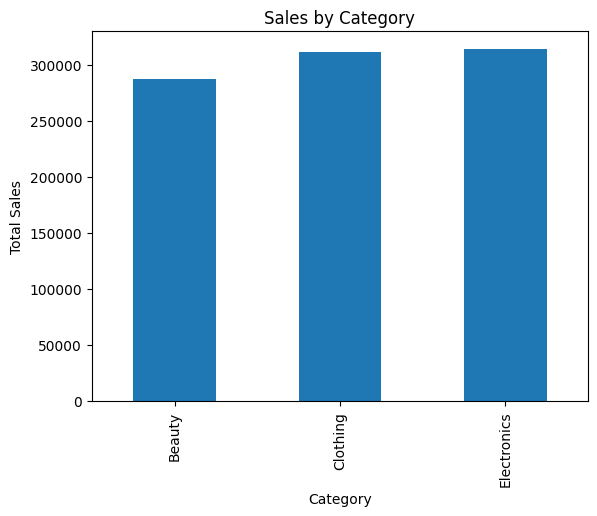

In [18]:
category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

Observation: Electronics generated the highest sales, followed closely by Clothing. Beauty had the lowest sales among the three categories.

In [19]:
gender_sales = df_clean.groupby('gender')['total_sale'].sum()
gender_sales

,total_sale
gender,
Female,465400.0
Male,446320.0


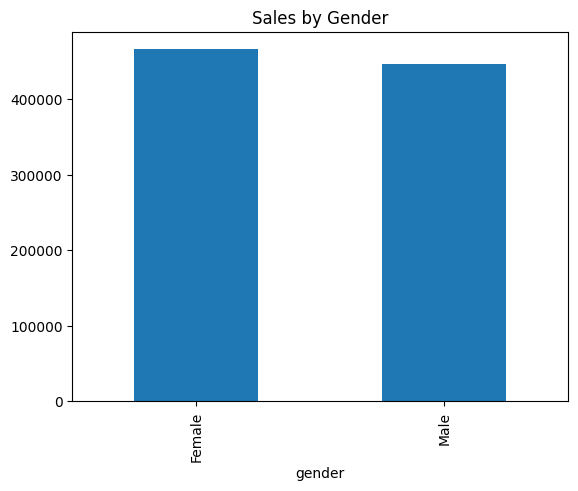

In [20]:
gender_sales.plot(kind='bar', title='Sales by Gender')
plt.show()

Observation: Female customers generated slightly higher total sales than male customers. However, the difference is relatively small, indicating that sales are fairly balanced across genders.

In [21]:
age_sales = df_clean.groupby('age')['total_sale'].sum()
age_sales

,total_sale
age,
18.0,22340.0
19.0,29690.0
20.0,17290.0
21.0,25170.0
22.0,27400.0
23.0,16440.0
24.0,10830.0
25.0,19800.0
26.0,27960.0


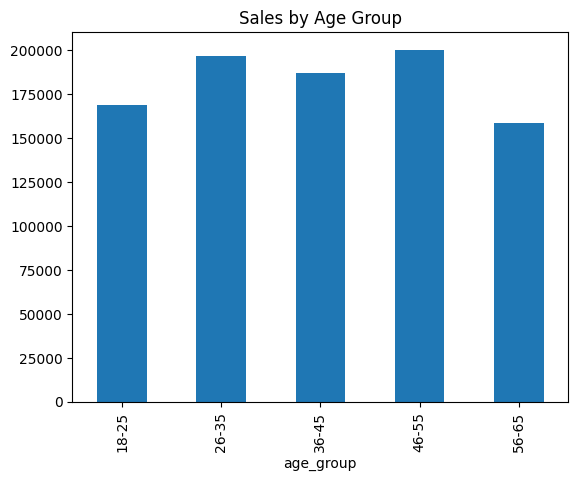

In [25]:
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[17, 25, 35, 45, 55, 65],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65']
)

age_sales = df_clean.groupby('age_group', observed=True)['total_sale'].sum()

age_sales.plot(kind='bar', title='Sales by Age Group')
plt.show()

Note: The dataset does not contain a product-level identifier or product name column. Therefore, product-level sales ranking could not be performed. Revenue by product category was analyzed instead.

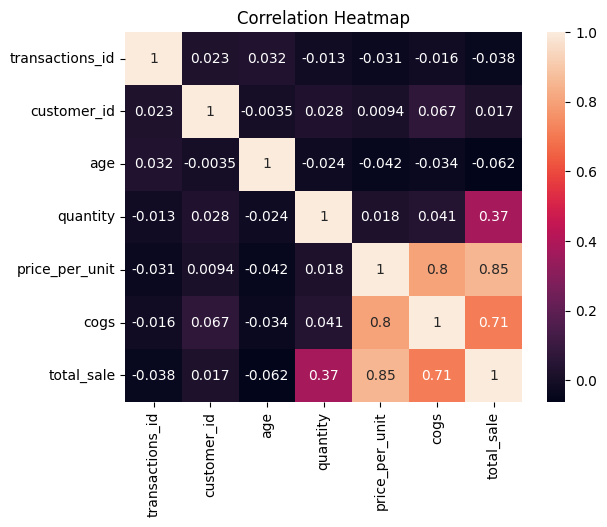

In [27]:
corr = df_clean.select_dtypes('number').corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

### Observation

The heatmap shows that total sales have a strong positive correlation with price per unit (0.85) and COGS (0.71). Quantity has a moderate positive correlation with total sales (0.37). Age has very little correlation with total sales (-0.062), indicating that age does not strongly influence sales in this dataset.

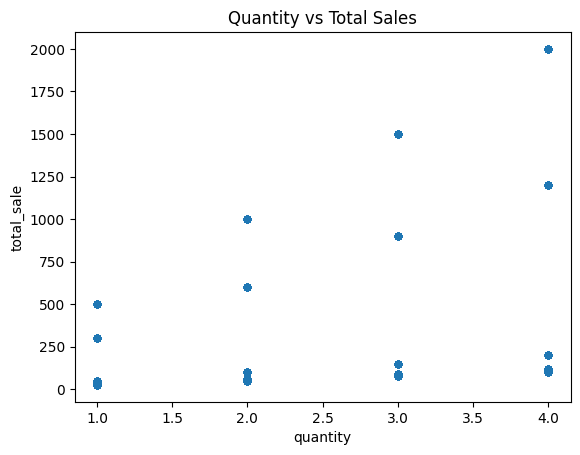

In [28]:
df_clean.plot(x='quantity', y='total_sale', kind='scatter', title='Quantity vs Total Sales')
plt.show()

### Observation

The scatter plot shows that total sales generally increase as the quantity purchased increases. However, there is considerable variation in sales for the same quantity, indicating that the price per unit also has an important effect on total sales.

# Conclusion

The analysis of the retail sales dataset revealed several important business insights. Sales varied considerably across different months and quarters, with some periods showing significantly higher revenue. Electronics generated the highest revenue among the product categories, while Beauty generated the lowest. Customers aged 46–55 contributed the highest sales among the age groups and female customers generated slightly higher total sales than male customers.

The correlation analysis showed that price per unit had the strongest relationship with total sales, followed by COGS and quantity. The quantity vs total sales analysis also showed that purchasing more units generally leads to higher sales, although the price of the products also plays an important role.

### Business Recommendations

1. **Focus on high-performing categories:** Increase inventory and marketing efforts for Electronics and Clothing, as these categories generate the highest revenue.

2. **Target high-value customer groups:** Develop targeted promotions for customers aged 26–55, particularly the 46–55 age group, which generated the highest sales.

3. **Use seasonal sales trends:** Increase inventory and promotional campaigns during high-performing months and quarters to take advantage of periods with higher customer demand.